In [1]:
import numpy as np
import torch
import torch.nn as nn

In [2]:
words = open("names.txt", "r").read().splitlines()

## Exploring bigram dataset

In [3]:
b = {}
## interate these words with consecutive characters sliding into the word
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 ## if bigram in b: b[bigram] = b[bigram] + 1; else:b[bigram] = 1

In [4]:
import torch

In [5]:
N = torch.zeros((27, 27), dtype=torch.int32) ## 26 characters + 1 special character

In [6]:
chars = sorted(list(set(''.join(words)))) 
## first compress all words into a whole big word, 
## and using the uniqle property of set() to get all uniqle characters then 
stoi = {s:i+1 for i, s in enumerate(chars)} ## enumerate keeps the index and the value simultaneously
stoi['.'] = 0 ## define the spatial character .
itos = {i:s for s, i in stoi.items()}


In [7]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] ## index of the characters in the alphabet
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 ## frequency of chars appears

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

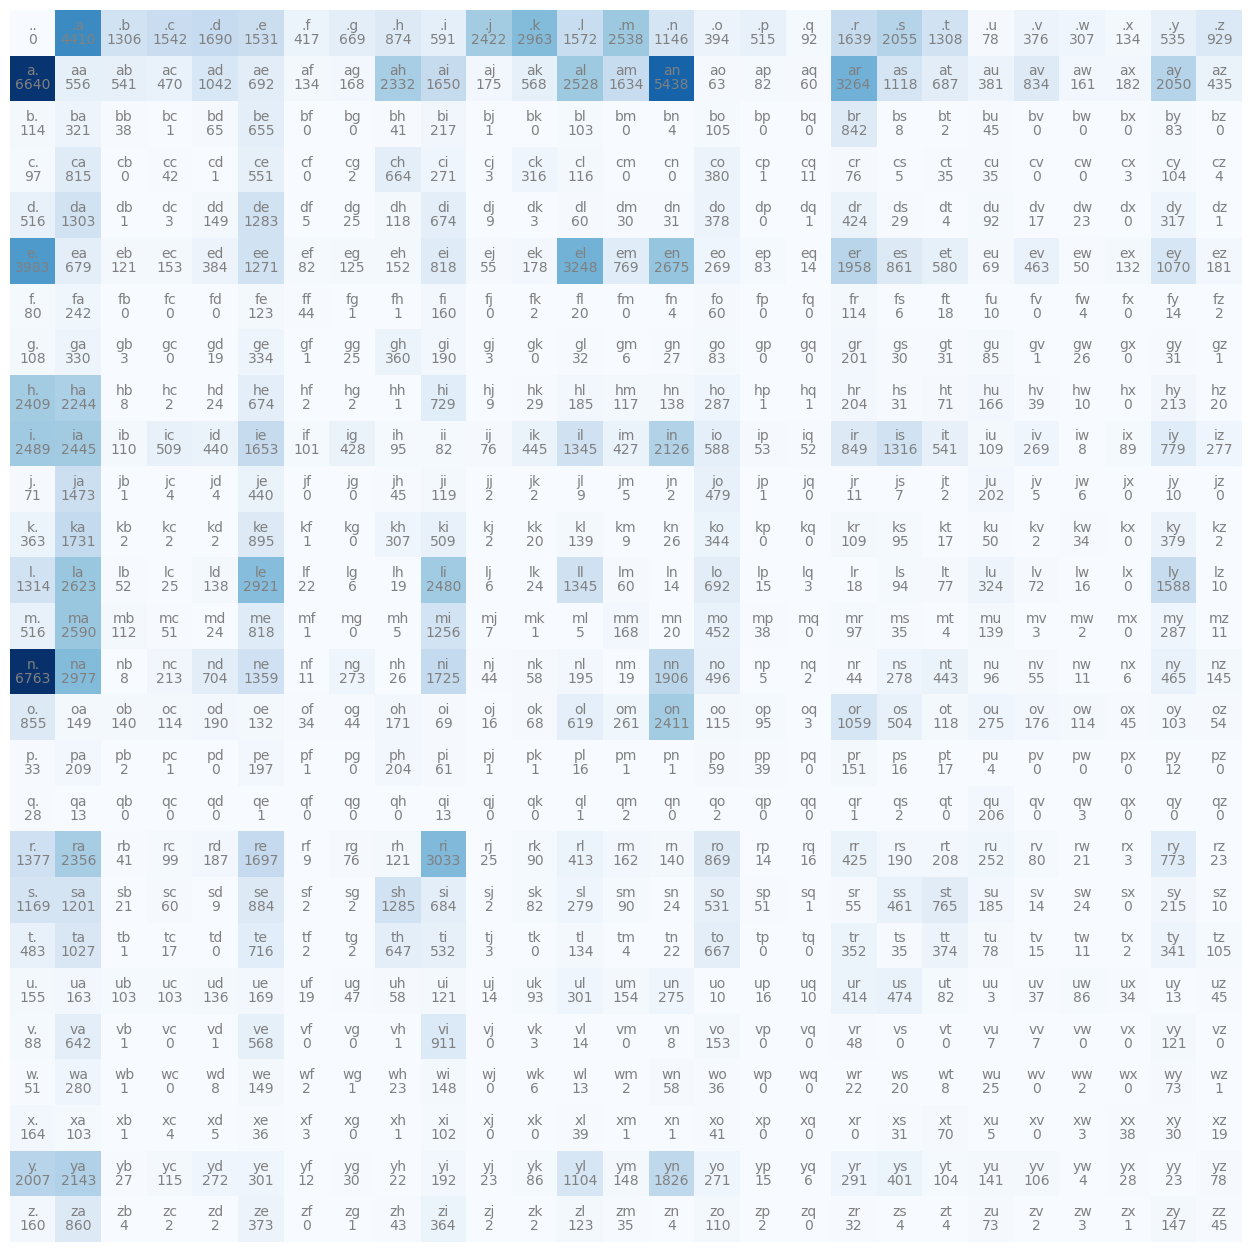

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color = 'gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color = 'gray')
plt.axis('off')


In [9]:
## Normalization with row
P = (N+1).float()
P /= P.sum(1, keepdims=True) 

In [10]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [11]:
## maximum the loglikelihood
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood}')
nll = -log_likelihood
print(f'{nll}')
print(f'{nll/n}')

-559951.5625
559951.5625
2.4543561935424805


In [ ]:
import torch.nn.functional as F

In [28]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [30]:
# gradient descent
for k in range(10):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.3788065910339355
3.161090850830078
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188305854797363
2.696505546569824


In [31]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

dexzmalegllusailezktxha.
kllimittain.
llayn.
ka.
da.


## Part 2 MLP